## Objective

The aim of this notebook is generate the P-Space graph from the cleaned L-Space graph

### Pre-requisites

In [3]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../')))

from utils.imports import *

In [4]:
attributes = load_gtfs(str(PATH_TO_SQLITE))
L_graph = load_graph(L_SPACE_PATH)
P_graph=load_graph(P_SPACE_PATH)

### Plot L-Space Graph

In [3]:
plot_graph(L_graph, back_map="OSM")

In [4]:
L_graph.number_of_edges()

1220

### Plot P-Space Graph

In [5]:
# plot_graph(P_graph,"P")

### Load shortests paths between all pairs of nodes.

In [6]:
gtc_loaded = load_gtc_from_pkl(DATA_DIR/"pkl/gtc_data_belgium.pkl")

GTC data loaded from C:\Users\KIIT\Documents\UAntwerp\railways_resilience\data\pkl\gtc_data_belgium.pkl


#### Understanding the results

For each pair of nodes we get as many paths as requested (or as many as available if there are fewer alternative paths).

The results is a dictionary, indexed by the nodes of origin (first index) and the nodes of destination (second index). For each pair of nodes we get a list, with the alternative paths ordered by GTC.

Each path is again modeled as a dictionary, including the following attributes:
- path: the sequence of nodes in the path computed in the L-space graph
- GTC: the GTC corresponding to that path
- in_vehicle: the in-vehicle travel time in minutes of that path
- waiting_time: the waiting-time in minutes of that path (from P-space)
- n_transfers: the number of transfers of that path (hops in P-space)

In [7]:
#Example: check the GTC between nodes 51 and 37
gtc_loaded[51][37]

{'path': [51, 50, 39, 38, 37],
 'GTC': 38,
 'in_vehicle': 19,
 'waiting_time': 7,
 'n_transfers': 1,
 'traveled_distance': 15828}

### Auxiliary functions

In [8]:
#Return the average waiting time (in minutes) per line and direction
average_waiting_time_per_line_per_direction(P_graph)

{79: {'Liège-Guillemins': 43.84615384615385,
  'Zottegem': 43.84615384615385,
  'Audenarde': 43.84615384615385,
  'Brussels Airport-Zaventem': 43.84615384615385,
  'Schaerbeek': 43.84615384615385,
  'Bruxelles-Midi': 43.84615384615385,
  'Denderleeuw': 43.84615384615385,
  'Louvain-la-Neuve': 43.84615384615385,
  'Grammont': 43.84615384615385,
  'Ostende': 43.84615384615385,
  'Courtrai': 43.84615384615385,
  'Amsterdam Sud': 43.84615384615385,
  'Namur': 43.84615384615385,
  'BERLIN HBF (D)': 43.84615384615385,
  'Welkenraedt': 43.84615384615385,
  'Lelystad Centre': 43.84615384615385,
  'Neerpelt': 43.84615384615385,
  'Mol': 43.84615384615385,
  'Landen': 43.84615384615385,
  'Hasselt': 43.84615384615385,
  'Ottignies': 43.84615384615385,
  'Arlon': 43.84615384615385,
  'Eupen': 43.84615384615385,
  'Essen': 43.84615384615385,
  'Alost': 43.84615384615385,
  'Rochefort-Jemelle': 43.84615384615385,
  'Rotterdam CS (NL)': 43.84615384615385,
  'Ciney': 43.84615384615385,
  'Genk': 43.8

In [9]:
#Return the average speed (in km/h) for the whole network
average_speed_network(L_graph)

58.347499797287156

In [10]:
#Get dataframe with all events
df=get_events(attributes,
              mode="Rail",
              start_hour=5,
              end_hour=24)
df.head()

Considering trips between 2025-02-21 05:00:00+01:00 and 2025-02-21 23:59:59+01:00


,from_stop_I,to_stop_I,dep_time_ut,arr_time_ut,shape_id,direction_id,headsign,route_type,route_id,trip_I,duration,from_seq,to_seq,route_I
0,939,971,1740116520,1740116940,None,None,Hasselt,2,200,7120,420,1,2,114
1,971,967,1740116940,1740117240,None,None,Hasselt,2,200,7120,300,2,3,114
2,967,975,1740117420,1740117660,None,None,Hasselt,2,200,7120,240,3,4,114
3,975,980,1740117660,1740117840,None,None,Hasselt,2,200,7120,180,4,5,114
4,980,984,1740117840,1740117900,None,None,Hasselt,2,200,7120,60,5,6,114


In [11]:
import networkx as nx

#Set a new attribute to edges
nx.set_edge_attributes(L_graph, 0, 'capacity') # Set attribute "capacity" with default value 0

In [12]:
#Plot the network and color nodes based on an attribute
plot_graph(L_graph, back_map="OSM", color_by="lat")

In [13]:
#Plot the network and color edges based on an attribute
plot_graph(L_graph, back_map="OSM", edge_color_by="duration_avg")

### Calculating topological indicators

In [14]:
# Basic properties
nodes = len(L_graph.nodes())
edges = len(L_graph.edges())
print(f"Nodes: {nodes}, Edges: {edges}")

Nodes: 558, Edges: 1220


In [15]:
# Graph diameter
diameter = nx.diameter(L_graph)
diameter_weighted = nx.diameter(L_graph, weight="duration_avg")
print(f"Diameter (unweighted): {diameter}, Diameter (weighted): {diameter_weighted}")

Diameter (unweighted): 57, Diameter (weighted): 17393.33254462918


- The **unweighted diameter** of the network is **57**, meaning the longest shortest path between any two nodes (in terms of number of hops) is 57.
- The **weighted diameter** is approximately **17,399 seconds (~4.83 hours)**, which represents the maximum in-vehicle travel time across the network.

This suggests that while the network may have many hops between distant nodes, the travel time can be quite significant — potentially due to low speeds, long distances, or fewer direct connections.

In [16]:
# Density and meshedness
density = nx.density(L_graph)
meshedness_val = meshedness(L_graph)
print(f"Density: {density}, Meshedness: {meshedness_val}")

Density: 0.003925278147783505, Meshedness: 0.04770477047704771


- The **density** of the network is **0.0039**, indicating a very sparse graph — only about 0.39% of all possible edges between nodes are present. This is expected for large-scale transportation systems like railway networks, where each node (station) typically connects to only a few others.

- The **meshedness** value is **0.0502**, which is relatively low. This metric reflects the proportion of actual cycles (alternative routes) compared to the maximum number possible in a planar graph. A value this low suggests that:
  - The network has **very limited redundancy**, meaning there are not many alternative paths available between stations.
  - In case of a link failure, **rerouting options are minimal**, increasing the vulnerability of the network to localized disruptions.

Together, these indicators show that the network is **more tree-like than grid-like**. This structure is typical in large transit systems optimized for coverage rather than resilience, but it also implies that **targeted failures (especially near high-traffic nodes) can significantly degrade performance** due to the lack of backup routes.

In [17]:
# Shortest path length
shortest_path = nx.average_shortest_path_length(L_graph)
shortest_path_weighted = nx.average_shortest_path_length(L_graph, weight="duration_avg")
print(f"Avg shortest path (unweighted): {shortest_path}, (weighted): {shortest_path_weighted}")

Avg shortest path (unweighted): 22.42106008249519, (weighted): 5415.721713497589


- The **average shortest path length (unweighted)** is **22.4**, meaning that on average, it takes about 22 hops (edges) to travel between any two nodes in the network.
- The **average shortest path length (weighted)** is approximately **5410 seconds (~1.5 hours)**, which accounts for the average in-vehicle travel time between stations.

The high average values in both cases reflect the **large size and low density** of the network — stations are often far apart both topologically (in number of hops) and temporally (in travel time). This also indicates that while the network is connected, it may not be **efficient in terms of travel time**, and **passenger experience can vary significantly** depending on distance and route availability.

Betweenness Centrality (unweighted): 9.226488894069123
Betweenness Centrality (weighted): 8.41176662496438


9.226488894069123

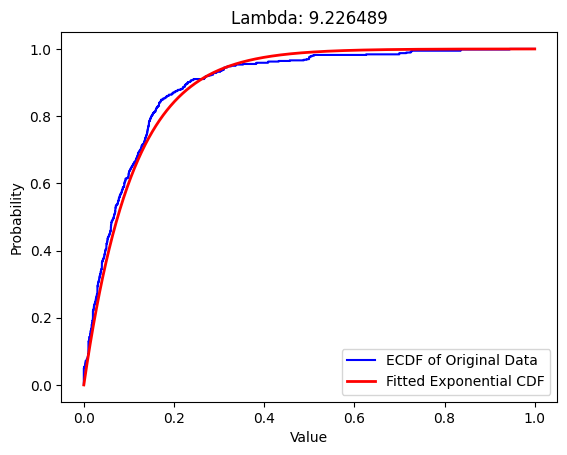

In [18]:
# Betweenness centrality with exponential fit
betweenness = betweenness_fit_revised(L_graph)
print(f"Betweenness Centrality (unweighted): {betweenness}")

betweenness_weighted = betweenness_fit_revised(L_graph, weight="duration_avg")
print(f"Betweenness Centrality (weighted): {betweenness_weighted}")

betweenness_fit_revised(L_graph, plot=True)

**Betweenness centrality** measures how often a node appears on the shortest paths between other pairs of nodes in the network.  
  - A higher value means a node is acting like a **bridge or hub**, playing a critical role in connecting different parts of the network.
  - In this analysis, the **average betweenness centrality** is approximately **8.65 for the unweighted graph** and **8.39 for the weighted graph (where edge weights reflect travel time)**.  
    This means that, on average, each node is involved in around 8–9 shortest paths between other node pairs.

The plot compares the **actual distribution** of betweenness values in the network (blue line) to a **theoretical exponential distribution** (red line).
  - The **exponential distribution** is commonly used to model phenomena where **many events have small values** and **a few have large ones** (like how most people know a few people, but a few people are extremely well-connected).
  - In this case, the **fit is quite close**, meaning **most nodes have low centrality**, while **a few key nodes are very central and carry much of the network's traffic**.

The **rate parameter (λ ≈ 8.65)** gives us a sense of how quickly the probabilities drop off.
  - A higher λ means that centrality values drop off quickly — i.e., **only a few nodes are highly influential**, and most are peripheral.
  - This distribution suggests a kind of **core-periphery structure**, where a small number of central nodes act as critical junctions.

This pattern has important implications:
  - The network is **efficient**, but it is also **vulnerable**.
  - If one of the **high-betweenness nodes** is removed (due to failure or attack), it can **severely disrupt connectivity**, increasing travel times and fragmenting the network.
  - Thus, understanding betweenness helps in planning **resilient transport systems**, identifying nodes that need **reinforcement, protection, or redundancy**.

In [19]:
# Degree assortativity coefficient
assortativity = nx.degree_assortativity_coefficient(L_graph)
print(f"Assortativity: {assortativity}")

Assortativity: -0.03948278889152834


The **degree assortativity coefficient** measures the tendency of nodes to connect with other nodes that have **similar degrees** (i.e., number of connections). Values range from **-1 to +1**:
- **Positive** values indicate that high-degree nodes tend to connect with other high-degree nodes (a "rich club" behavior).
- **Negative** values suggest that high-degree nodes tend to connect with low-degree nodes (a hub-and-spoke pattern, like star-shaped networks).
- A value near **zero** implies **no strong correlation** in connection patterns.

In this network, the coefficient is approximately **-0.0055**, which is **very close to zero**.
  - This means the network is **essentially neutral** in terms of assortativity.
  - There's **no strong preference** for nodes to connect with others of similar or dissimilar connectivity.

Why does this matter?
  - This neutrality could suggest a **balanced structure**, without overly dominant hubs or tight elite clusters.
  - It might also reflect the **functional nature** of the transport network: connections are likely based more on **geographic or service logic** (e.g., proximity, coverage) rather than structural preference.

In [20]:
# Clustering Coefficient
clustering_coeff = nx.average_clustering(L_graph)
print(f"Average Clustering Coefficient: {clustering_coeff}")

Average Clustering Coefficient: 0.007168458781362007


The **average clustering coefficient** of `0.0111` indicates a very low level of local connectivity in the network. This means that if two stops share a common neighbor, it's unlikely that they are directly connected themselves.

- The network has a **sparse or tree-like structure** with limited triangular connections.
- This suggests **low local redundancy**, meaning there are few alternate routes between neighboring nodes.
- Such a structure is typical in large-scale transportation networks where cost-efficiency is prioritized over local connectivity.

In [21]:
plot_top_hubs(L_graph, top_n=10)

Highlighted Nodes:
  Node 36: Louvain
  Node 38: Liège-Guillemins
  Node 120: Malines
  Node 0: Courtrai
  Node 15: Gand-Saint-Pierre
  Node 22: Bruxelles-Midi
  Node 164: Charleroi-Central
  Node 172: Hasselt
  Node 228: Ottignies
  Node 237: Etterbeek


,Node,Node Name,Degree
0,36,Louvain,12
1,38,Liège-Guillemins,12
2,120,Malines,12
3,0,Courtrai,10
4,15,Gand-Saint-Pierre,10
5,22,Bruxelles-Midi,10
6,164,Charleroi-Central,10
7,172,Hasselt,10
8,228,Ottignies,10
9,237,Etterbeek,10


In [22]:
# Eccentricity and Radius
eccentricity_dict = nx.eccentricity(L_graph)
radius = nx.radius(L_graph)

# Node with minimum eccentricity (most central node by reach)
central_node = min(eccentricity_dict, key=eccentricity_dict.get)

print(f"Graph Radius: {radius}")
print(f"Most central node by eccentricity: {central_node} with value {eccentricity_dict[central_node]}")

Graph Radius: 33
Most central node by eccentricity: 244 with value 33


 **Graph Radius** is **32**, meaning the most "centrally located" node in the network is at most 32 hops away from any other node.
- **Node 245** has the **minimum eccentricity (32)**, making it the **most central node** in terms of topological reach.
- Such nodes are ideal candidates for:
  - Central dispatching points
  - Emergency service hubs
  - Key transfer stations
- A low radius implies **relatively good reachability** across the network, which is desirable in transport systems.

In [23]:
plot_graph_highlight_node(L_graph, highlight_nodes=[central_node], back_map="OSM")

Highlighted Nodes:
  Node 244: Rixensart


In [24]:
# Weighted eccentricity and radius using 'duration_avg' as travel time
eccentricity_dict = nx.eccentricity(L_graph, weight="duration_avg")

radius = nx.radius(L_graph, weight="duration_avg")
central_node = min(eccentricity_dict, key=eccentricity_dict.get)

print(f"Weighted Graph Radius (in time): {radius:.2f}")
print(f"Most central node by travel time: {central_node}")

Weighted Graph Radius (in time): 8777.25
Most central node by travel time: 248


**Weighted Graph Radius**: **8777.25 seconds** – the most central node (248) is at most 8777.25 seconds (~2.44 hours) away from any other node.
- **Node 248** has the **minimum eccentricity (8777.25 seconds) (~2.44 hours)**, making it the **most central node** in terms of travel time.
- Ideal for:
  - **Key transit hubs**
  - **Strategic scheduling points**
  - **Service improvements**
- A low weighted radius suggests **efficient travel** and **network optimization**.

In [5]:
plot_graph_highlight_node(L_graph, highlight_nodes=[7], back_map="OSM")

Highlighted Nodes:
  Node 7: Poperinge
